In [1]:
from typing import Annotated, TypedDict, Literal, List
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, CachePolicy, interrupt, Send
from langgraph.runtime import Runtime
from langgraph.types import RetryPolicy, TimeoutPolicy
from langgraph.errors import NodeError
from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, ToolMessage
)
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from IPython.display import Image, display
from operator import add
from dotenv import load_dotenv
from pydantic.dataclasses import dataclass
from pydantic import BaseModel, Field

load_dotenv()

def display_graph(graph, xray=False):
    """显示图结构，xray = True 可展开子图内部结构"""
    display(Image(graph.get_graph(xray = xray).draw_mermaid_png()))

llm = init_chat_model("deepseek-chat")

# 1. 顺序执行（Prompt Chaining）

Prompt Chaining 是最基础的编排模式：前一个LLM的输出作为后一个LLM的输入，像流水线一样串联起来。

与直接 LLM 调用的区别: 顺序链可以在步骤之间加入验证门控（Gate）——如果某步质量不达标就退回重做，而不是一路到底。

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field

class JokeState(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

def generate_joke(state: JokeState):
    """生成初稿"""
    msg = llm.invoke(f"write a short joke about {state['topic']}")
    return {"joke": msg.content, "final_joke": msg.content}

def check_punchline(state: JokeState):
    """门控函数：检查笑话是否有笑点"""
    msg = llm.invoke(f"Check if the joke has punchline and wordplay, return 'Pass' or 'Fail' for the joke: ```{state['joke']}```")
    result = msg.content

    if "Pass" == result:
        print(f"[检查]通过✅️")
        return "Pass"
    print(f"[检查]不通过❌️")
    return "Fail"

def improve_joke(state: JokeState):
    """改进——增加双关语"""
    print(f"  [润色] 添加双关语...")
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: JokeState):
    """步骤3: 润色——加一个反转"""
    print(f"  [润色] 添加反转...")
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


chaining_graph = (
    StateGraph(JokeState)
    .add_node("generate_joke", generate_joke)
    .add_node("improve_joke", improve_joke)
    .add_node("polish_joke", polish_joke)

    .add_edge(START, "generate_joke")
    # 条件边：通过则直接结束，不通过则进入改进流程
    .add_conditional_edges(
        "generate_joke",
        check_punchline,
        {"Pass": END, "Fail": "improve_joke"}
    )
    .add_edge("improve_joke", "polish_joke")
    .add_edge("polish_joke", END)
    .compile()
)

print("=== 测试1: 话题「大树」 ===\n")
r = chaining_graph.invoke({"topic": "大树", "joke": "", "improved_joke": "", "final_joke": ""})
print(f"\n最终笑话:\n{r['final_joke']}")

# 2. 并行执行（Parallelization）

通过并行化，可以让多个LLM同时处理一个任务，有两种不同的实现方式和作用：
- 提高效率: 将任务拆分为子任务，让多个LLM同时运行独立的子任务来完成，再汇总结果
- 提高准确度: 多个LLM运行相同的任务产生不同的输出，再合并优化结果

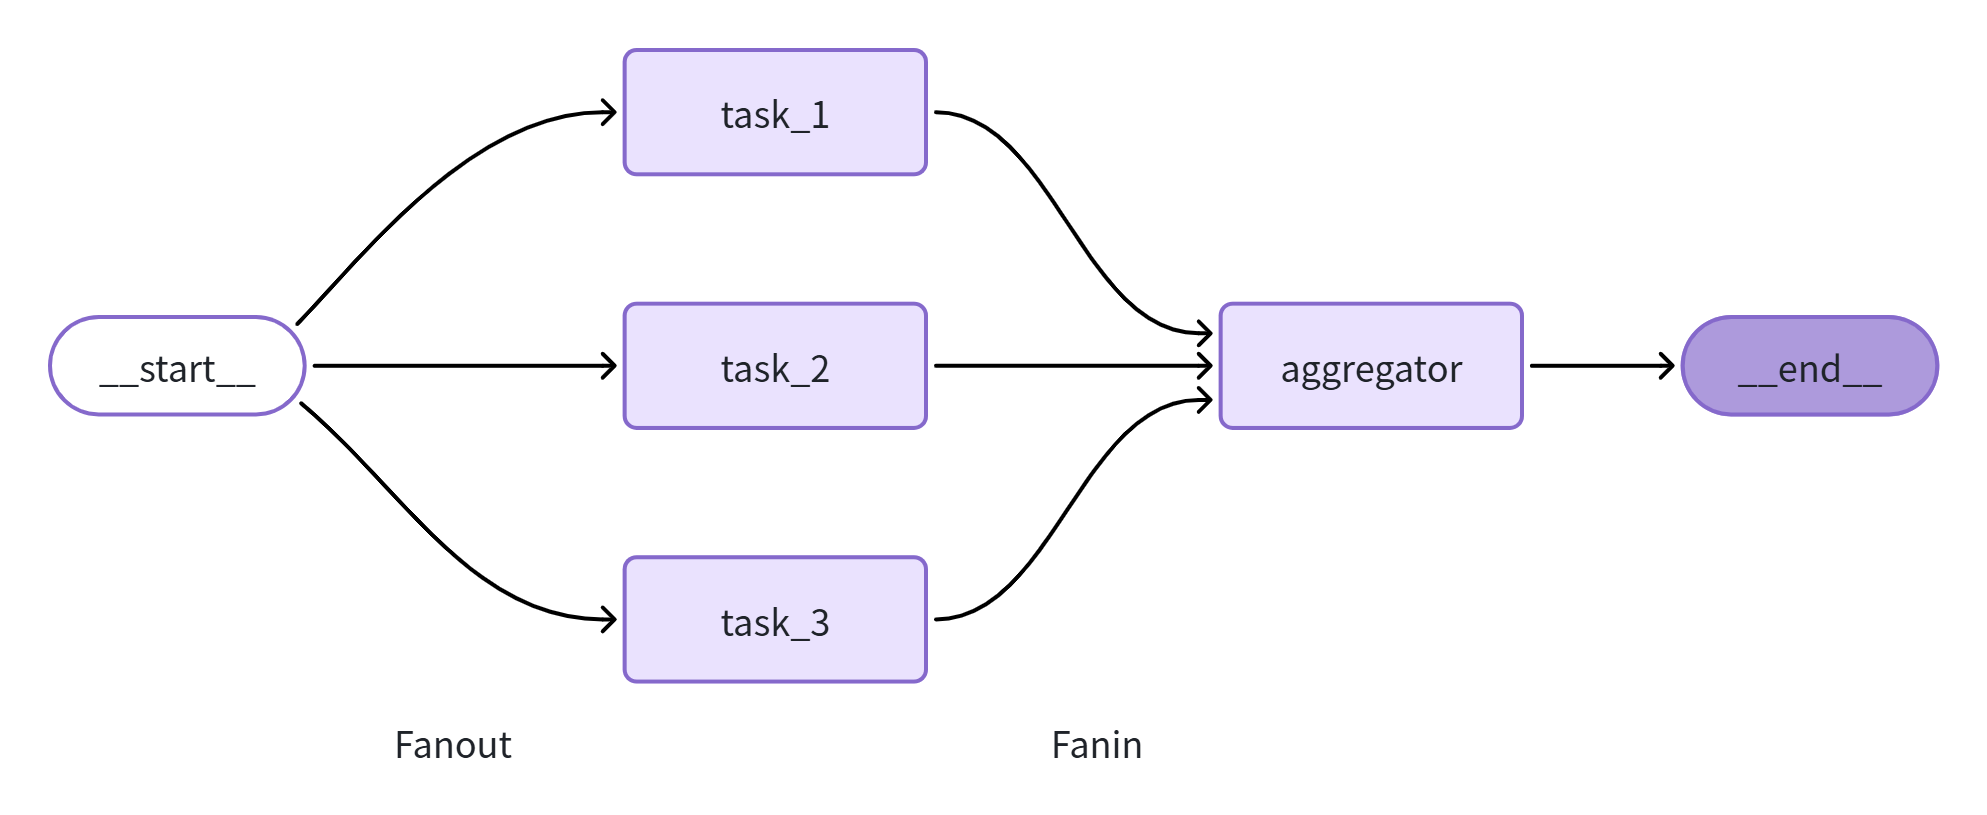

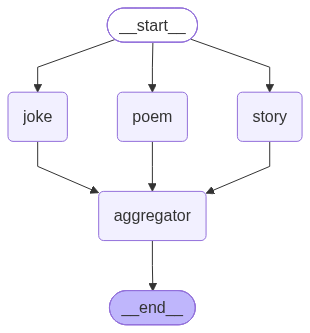

In [3]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

# Nodes
def joke_node(state: State):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}

def story_node(state: State):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}

def poem_node(state: State):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}

def aggragator(state: State):
    """Combine the joke, story and poem into a single output"""
    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"

    return {"combined_output": combined}

# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("joke", joke_node)
parallel_builder.add_node("story", story_node)
parallel_builder.add_node("poem", poem_node)
parallel_builder.add_node("aggregator", aggragator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "joke")
parallel_builder.add_edge(START, "story")
parallel_builder.add_edge(START, "poem")
parallel_builder.add_edge("joke", "aggregator")
parallel_builder.add_edge("story", "aggregator")
parallel_builder.add_edge("poem", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

display_graph(parallel_workflow)

# 3. 路由（Routing）

Routing工作流处理用户输入，然后将它们引导到上下文相关的任务Node。这允许您为复杂的任务定义专门的流。例如：
- 智能电商客服，首先识别问题的类型，然后将请求路由到 售前咨询、退款、退货等对应的Node。
- 知识问答机器人，首先识别问题知识领域，然后将请求路由到不同领域对应的专业Node上。

所以路由本质上也是条件分支，让Graph根据问题动态选择下一节点。这是Agent智能决策的核心机制。

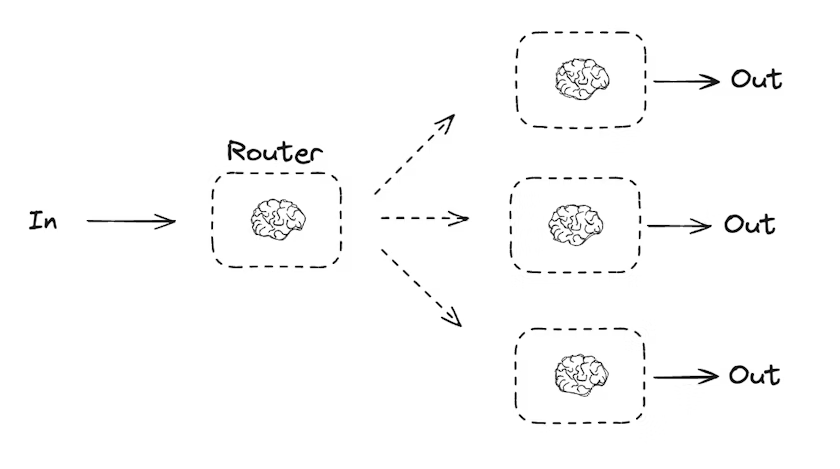

写三个工作节点：
- 天气节点：可以查询天气
- 新闻节点：可以查询新闻
- 翻译节点：可以翻译

然后写一个意图识别节点，根据用户意图路由到对应的工作节点，执行对应任务：

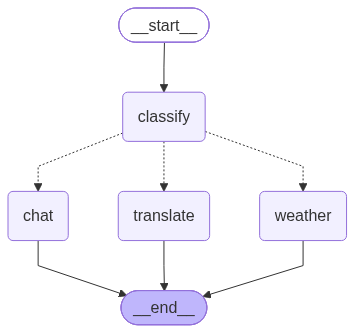

In [5]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage, SystemMessage

# 定义作为路由逻辑的结构化输出模型
class Route(BaseModel):
    step: Literal["weather", "translate", "chat"] = Field(
        None, description="The next step in the routing process"
    )

# 把路由结构化输出绑定到模型，形成一个用于路由的llm
# 这行是在给 LLM 绑定一个结构化输出格式，让它返回的不是自由文本，而是符合 Route schema 的对象。
router = llm.with_structured_output(Route)

class IntentState(TypedDict):
    query: str
    intent: str
    result: str

def classify_intent(state: IntentState):
    """分类用户意图"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(  # decision 是 Route 实例
        [
            SystemMessage(
                content= "Route the input to weather, translate, or chat based on the user's request."
            ),
            HumanMessage(content=state["query"])
        ]
    )

    return {"intent": decision.step}

def handle_weather(state: IntentState):
    return {"result": f"天气查询: {state['query']} -> 晴 25度"}

def handle_translate(state: IntentState):
    return {"result": f"翻译: {state['query']} -> Hello World"}

def handle_chat(state: IntentState):
    return {"result": f"闲聊: {state['query']} -> 你好呀！"}

def intent_router(state: IntentState) -> Literal["weather", "translate", "chat"]:
    """根据意图路由到不同处理器"""
    return state['intent']

routing_graph = (
    StateGraph(IntentState)
    .add_node("classify", classify_intent)
    .add_node("weather", handle_weather)
    .add_node("translate", handle_translate)
    .add_node("chat", handle_chat)

    .add_edge(START, "classify")
    .add_conditional_edges(
        "classify",
        intent_router,
        {
            "weather": "weather",
            "translate": "translate",
            "chat": "chat"
        }
    )
    .add_edge("weather", END)
    .add_edge("translate", END)
    .add_edge("chat", END)

    .compile()
)

display_graph(routing_graph)